In [11]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Visualizing Contributor Co-occurrence in the ProvedIt Dataset

This notebook explores the contributor structure of the ProvedIt dataset. The goal is to analyze how contributors co-occur within files and visualize their relationships using an arc diagram.

In [12]:
from itertools import combinations
from collections import Counter
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer, categorize_files
from DNAnet.data.parsing.file_parsing import find_files_by_suffix

import matplotlib.pyplot as plt
import numpy as np
import re

## Extract Contributor Pairs

We define a function to extract all unique pairs of contributor IDs from each file. Only files with at least two contributors are considered, and all possible unordered pairs are generated for further analysis.

In [13]:
def extract_all_pairs(files):
    pairs = []
    for f in files:
        ids = ProvedItFileCategorizer.extract_contributor_ids(f.name)
        # Only consider files with at least 2 contributors
        if len(ids) >= 2:
            # Get all unique pairs (order doesn't matter)
            pairs.extend(combinations(sorted(ids), 2))
    return pairs

## Load Dataset Files

Specify the path to the dataset and load all files with the `.hid` suffix. These files are used to extract contributor information.

In [14]:
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"

hid_files = find_files_by_suffix(hid_files_path, ".hid")

## Categorize Files and Extract Mixture Samples

Categorize the loaded files using the custom file categorizer and extract the subset of files labeled as 'sample', which represent mixture samples.

In [15]:
categorized_files = categorize_files(hid_files, ProvedItFileCategorizer())
mixture_samples = categorized_files["sample"]

## Check Number of Mixture Samples

Display the number of mixture samples identified in the dataset.

In [16]:
len(mixture_samples)

675

## Extract and Count Contributor Pairs

Extract all contributor pairs from the files and count the frequency of each pair's co-occurrence.

In [32]:
pairs = extract_all_pairs(hid_files)
pairs_count = Counter(pairs)
pairs_count.most_common(10)

[((33, 34), 122),
 ((36, 37), 107),
 ((29, 50), 100),
 ((44, 45), 99),
 ((31, 32), 98),
 ((37, 38), 97),
 ((29, 49), 84),
 ((49, 50), 84),
 ((30, 31), 83),
 ((46, 47), 83)]

## Visualize Contributor Co-occurrence

Define a function to visualize contributor co-occurrence as an arc diagram. Each contributor is represented along a line, and arcs connect contributors who appear together in the same file.

In [19]:
def plot_arc_diagram(pairs, num_ids=50):
    plt.figure(figsize=(16, 4))
    y = np.zeros(num_ids)
    x = np.arange(1, num_ids + 1)
    plt.scatter(x, y, s=50, color='black')

    for a, b in pairs:
        # Draw an arc between a and b
        mid = (a + b) / 2
        radius = abs(b - a) / 2
        theta = np.linspace(0, np.pi, 100)
        arc_x = mid + radius * np.cos(theta)
        arc_y = radius * np.sin(theta)
        plt.plot(arc_x, arc_y, color='blue', alpha=0.3)

    plt.yticks([])
    plt.xlabel("Contributor ID")
    plt.title("Contributor Co-occurrence Arc Diagram")
    plt.show()

## Plot the Arc Diagram

Generate and display the arc diagram to visualize the relationships between contributors based on their co-occurrence in files.

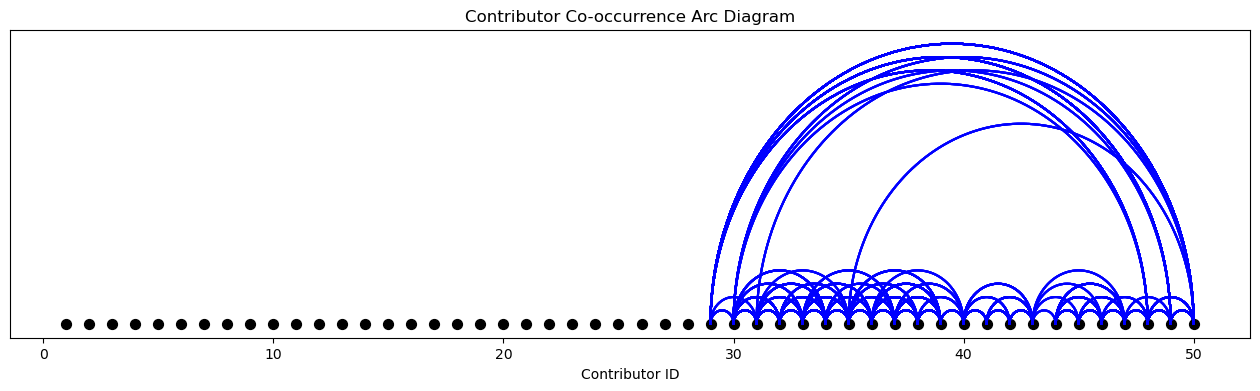

In [20]:
plot_arc_diagram(pairs)

## Extract Mixture Ratios from Filenames

We define a function to extract the mixture ratios from each filename. The mixture ratio is found as a comma-separated list after the contributor IDs. For example, in the filename `A05_RD14-0003-32_33_34_35-1,1,9,1-M2e-0.372GF-Q0.6_01.5sec.hid`, the mixture ratio is `1,1,9,1`.

In [21]:
def extract_mixture_ratios(file_name):
    """
    Extracts the mixture ratios from a ProvedIt filename as a list of integers.
    Returns an empty list if not found.
    """
    # Look for the pattern after the contributor IDs: -1,1,9,1-
    match = re.search(r"RD14-0003-[\d_]+-([\d,]+)-", file_name)
    if match:
        ratio_str = match.group(1)
        return [int(x) for x in ratio_str.split(",") if x.isdigit()]
    return []

## Aggregate Mixture Ratios

We extract the mixture ratios for all files and aggregate them for further analysis and visualization.

In [22]:
all_mixture_ratios = [extract_mixture_ratios(f.name) for f in hid_files if extract_mixture_ratios(f.name)]
all_mixture_ratios[:5]  # Show a sample

[[1, 2], [1, 2], [1, 1], [1, 2], [1, 4]]

## Visualize Contributor Mixes as Sets of (Ratio, Count) Tuples

We represent each mixture as a set of (ratio, count) tuples, where each tuple indicates a unique ratio and how many contributors have that ratio. The order of tuples does not matter. We then group and count all unique sets and visualize their frequencies as a bar chart.

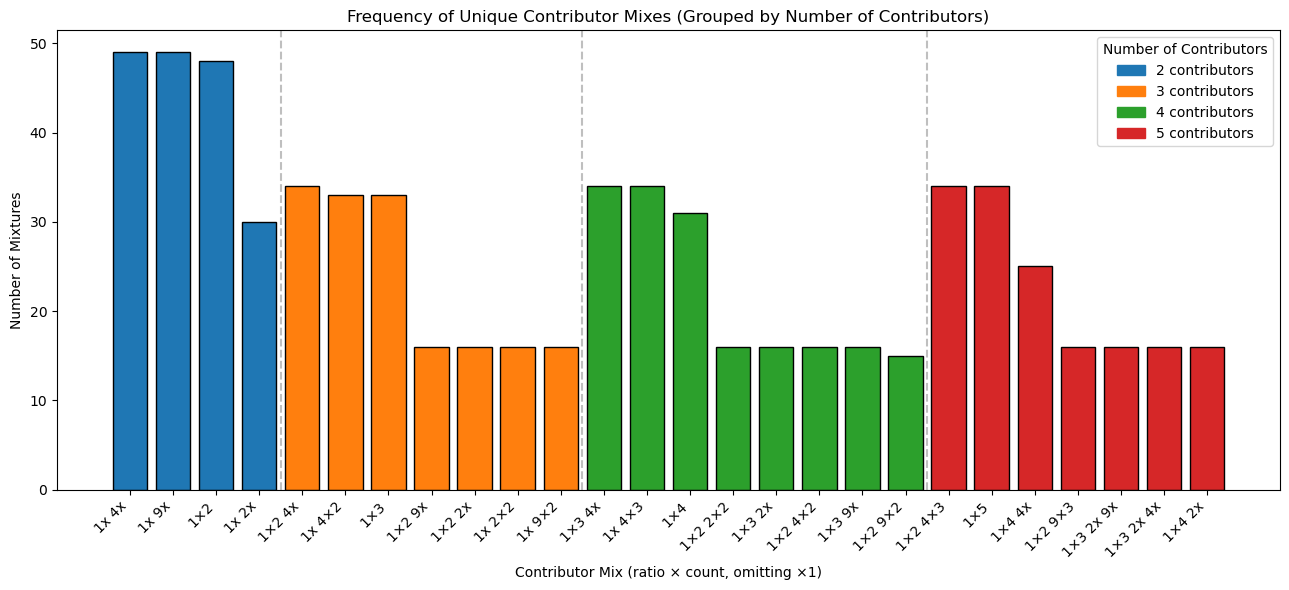

In [38]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

def mixture_to_tuple_set(mixture):
    c = Counter(mixture)
    return frozenset((ratio, count) for ratio, count in sorted(c.items()))

# Aggregate all unique sets and group by number of contributors
mixture_sets = [mixture_to_tuple_set(r) for r in all_mixture_ratios if r]
set_counts = Counter(mixture_sets)

# Group by number of contributors
grouped = defaultdict(list)
for s, count in set_counts.items():
    n_contrib = sum(cnt for _, cnt in s)
    grouped[n_contrib].append((s, count))

# Prepare for plotting
colors = plt.cm.tab10.colors  # Up to 10 groups, can expand if needed
all_labels = []
all_counts = []
all_colors = []
group_positions = []
current_pos = 0

for idx, n_contrib in enumerate(sorted(grouped.keys())):
    group = grouped[n_contrib]
    # Sort by count descending
    group_sorted = sorted(group, key=lambda x: -x[1])
    for s, count in group_sorted:
        label = " ".join(
            f"{ratio}x" if cnt == 1 else f"{ratio}×{cnt}"
            for ratio, cnt in sorted(s)
        )
        all_labels.append(label)
        all_counts.append(count)
        all_colors.append(colors[idx % len(colors)])
    group_positions.append(current_pos)
    current_pos += len(group_sorted)

plt.figure(figsize=(max(12, len(all_labels) * 0.5), 6))
bars = plt.bar(range(len(all_counts)), all_counts, color=all_colors, edgecolor='black')
plt.xticks(range(len(all_labels)), all_labels, rotation=45, ha='right')
plt.xlabel('Contributor Mix (ratio × count, omitting ×1)')
plt.ylabel('Number of Mixtures')
plt.title('Frequency of Unique Contributor Mixes (Grouped by Number of Contributors)')

# Add legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=colors[idx % len(colors)], label=f'{n_contrib} contributors')
    for idx, n_contrib in enumerate(sorted(grouped.keys()))
]
plt.legend(handles=legend_handles, title='Number of Contributors')

# Optionally, add vertical lines to separate groups
for pos in group_positions[1:]:
    plt.axvline(pos - 0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [39]:
import numpy as np

def gini_coefficient(x):
    """Compute the Gini coefficient of a list of numbers."""
    x = np.array(x)
    if np.amin(x) < 0:
        raise ValueError("Values cannot be negative")
    if np.amin(x) == 0 and np.amax(x) == 0:
        return 0.0
    x_sorted = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x_sorted)
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return gini

# Compute Gini for each mixture
gini_per_mixture = [gini_coefficient(r) for r in all_mixture_ratios if r]

# Group by number of contributors
gini_by_group = defaultdict(list)
for r, g in zip(all_mixture_ratios, gini_per_mixture):
    n = len(r)
    gini_by_group[n].append(g)

# Calculate average Gini per group
avg_gini_by_group = {n: np.mean(ginis) for n, ginis in gini_by_group.items()}

# Calculate average Gini over the whole dataset
avg_gini_overall = np.mean(gini_per_mixture)

print("Average Gini coefficient by number of contributors:")
for n in sorted(avg_gini_by_group):
    print(f"{n} contributors: {avg_gini_by_group[n]:.3f}")

print(f"\nAverage Gini coefficient over all mixtures: {avg_gini_overall:.3f}")

Average Gini coefficient by number of contributors:
2 contributors: 0.223
3 contributors: 0.218
4 contributors: 0.229
5 contributors: 0.232

Average Gini coefficient over all mixtures: 0.225


In [47]:
np.mean([gini_coefficient([1,1,4]), gini_coefficient([1,4,4]), gini_coefficient([1,1,1]), gini_coefficient([1,1,9]), gini_coefficient([1,1,2]), gini_coefficient([1,2,2]), gini_coefficient([1,9,9])])

0.23158654211285787

## Distribution of number of contributors per mixture

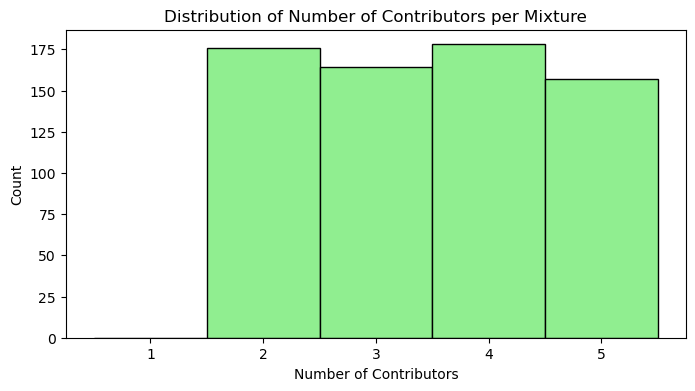

Counter({4: 178, 2: 176, 3: 164, 5: 157})

In [27]:
num_contributors = [len(r) for r in all_mixture_ratios]
plt.figure(figsize=(8,4))
plt.hist(num_contributors, bins=range(1, max(num_contributors)+2), align='left', color='lightgreen', edgecolor='black')
plt.xlabel('Number of Contributors')
plt.ylabel('Count')
plt.title('Distribution of Number of Contributors per Mixture')
plt.show()

# Distribution of number of contributors per mixture
num_contributors_count = Counter(num_contributors)
num_contributors_count